# 02 — Data Preprocessing

**Objective:** Clean the modeling dataset from EDA — drop leakage/redundant columns, handle missing values, parse features, treat outliers, and perform a vintage-based train/test split.

**Input:** `df_model_raw.csv` — 1,348,099 loans, 157 columns (151 original + 6 EDA-derived)

**Output:** Clean train/test splits (101 features each) + defaulted loans subset for EAD/LGD modeling

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Load Modeling Dataset

In [19]:
df = pd.read_csv('../data/df_model_raw.csv', low_memory=False)
print(f"Shape: {df.shape}")
print(f"Default rate: {df['default'].mean():.4f}")
df.head(3)

Shape: (1348099, 157)
Default rate: 0.1998


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,...,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default,fico_avg,fico_bin,issue_date,issue_year,issue_month
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.00,Aug-2003,675.00,679.00,1.00,30.00,NaN,7.00,0.00,2765.00,29.70,13.00,w,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0,677.00,"(660, 680]",2015-12-01,2015,2015-12
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.00,Dec-1999,715.00,719.00,4.00,6.00,NaN,22.00,0.00,21470.00,19.20,38.00,w,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0,717.00,"(700, 720]",2015-12-01,2015,2015-12
2,68341763,NaN,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,0.00,Aug-2000,695.00,699.00,0.00,NaN,NaN,6.00,0.00,7869.00,56.20,18.00,w,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0,697.00,"(680, 700]",2015-12-01,2015,2015-12


## 2. Column Removal

Dropping 91 columns across six passes (157 → 66 columns):

| Pass | Category | Count | Details |
|------|----------|------:|---------|
| 1 | Leakage | 38 | Post-outcome payment, recovery, settlement, hardship fields |
| 2 | ID / text / URL | 7 | `id`, `member_id`, `url`, `desc`, `emp_title`, `title`, `zip_code` |
| 3 | Single-value | 7 | `member_id`, `pymnt_plan`, `policy_code`, `hardship_flag`, `hardship_type`, `deferral_term`, `hardship_length` |
| 4 | High missing (>50%) | 58 | Joint app fields (`sec_app_*`, `annual_inc_joint`, `dti_joint`), delinquency history (`mths_since_last_delinq/record/major_derog`), `desc`, and remaining hardship/settlement fields |
| 5 | Redundant | 4 | `funded_amnt`, `funded_amnt_inv`, `grade`, `loan_status` |
| 6 | EDA-derived | 5 | `fico_avg`, `fico_bin`, `issue_date`, `issue_month`, `issue_year` |

Note: Many columns appear in multiple passes (e.g., `member_id` is both single-value and high-missing). After deduplication: **91 unique columns dropped, 66 remaining.**

In [20]:
# --- Pass 1: Leakage columns (known only after loan outcome) ---
leakage_cols = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'deferral_term', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'disbursement_method'
]

# --- Pass 2: ID / text / URL columns ---
id_cols = ['id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code']

# --- Pass 3: Single-value columns ---
single_val_cols = [col for col in df.columns if df[col].nunique() <= 1]

# --- Pass 4: High missing (>50%) ---
missing_pct = df.isnull().mean() * 100
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

# --- Pass 5: Redundant columns ---
# Note: fico_range_low & fico_range_high kept here — merged into fico_score in Section 3.13
redundant_cols = [
    'funded_amnt',       # nearly identical to loan_amnt
    'funded_amnt_inv',   # nearly identical to loan_amnt
    'grade',             # captured by sub_grade
    'loan_status',       # target is 'default'
]

# --- Pass 6: EDA-derived temporary columns ---
eda_temp_cols = ['fico_avg', 'fico_bin', 'issue_date', 'issue_month', 'issue_year']

# Combine all, deduplicate
all_drops = list(set(
    leakage_cols + id_cols + single_val_cols + high_missing_cols +
    redundant_cols + eda_temp_cols
))
all_drops = [c for c in all_drops if c in df.columns and c != 'default']

print(f"Leakage:       {len([c for c in leakage_cols if c in df.columns])}")
print(f"ID/text:       {len([c for c in id_cols if c in df.columns])}")
print(f"Single-value:  {len(single_val_cols)}")
print(f"High missing:  {len([c for c in high_missing_cols if c in df.columns])}")
print(f"Redundant:     {len([c for c in redundant_cols if c in df.columns])}")
print(f"EDA temp:      {len([c for c in eda_temp_cols if c in df.columns])}")
print(f"\nTotal unique columns to drop: {len(all_drops)}")
print(f"Columns before: {df.shape[1]}")

df.drop(columns=all_drops, inplace=True)
print(f"Columns after:  {df.shape[1]}")

Leakage:       38
ID/text:       7
Single-value:  7
High missing:  58
Redundant:     4
EDA temp:      5

Total unique columns to drop: 91
Columns before: 157
Columns after:  66


In [21]:
print("Remaining columns:")
for i, col in enumerate(sorted(df.columns)):
    miss = df[col].isnull().mean() * 100
    print(f"  {i+1:>2}. {col:<35} {str(df[col].dtype):<12} missing: {miss:.1f}%")

Remaining columns:
   1. acc_now_delinq                      float64      missing: 0.0%
   2. acc_open_past_24mths                float64      missing: 3.7%
   3. addr_state                          object       missing: 0.0%
   4. annual_inc                          float64      missing: 0.0%
   5. application_type                    object       missing: 0.0%
   6. avg_cur_bal                         float64      missing: 5.2%
   7. bc_open_to_buy                      float64      missing: 4.7%
   8. bc_util                             float64      missing: 4.8%
   9. chargeoff_within_12_mths            float64      missing: 0.0%
  10. collections_12_mths_ex_med          float64      missing: 0.0%
  11. default                             int64        missing: 0.0%
  12. delinq_2yrs                         float64      missing: 0.0%
  13. delinq_amnt                         float64      missing: 0.0%
  14. dti                                 float64      missing: 0.0%
  15. earliest_

## 3. Feature Parsing & Cleaning

Transforming the 66 remaining columns — converting strings to numeric, engineering date-based features, consolidating rare categories, and creating binary flags. After this section the dataset has **66 columns** (some added, some dropped — net zero change).

### 3.1 Term — strip text, convert to integer

`' 36 months'` / `' 60 months'` → `36` / `60`

In [22]:
print(f"Before: {df['term'].unique()}")
df['term'] = df['term'].str.strip().str.replace(' months', '', regex=False).astype(int)
print(f"After:  {df['term'].unique()}")

Before: [' 36 months' ' 60 months']
After:  [36 60]


### 3.2 Interest Rate — ensure numeric

Already `float64` in this dataset. Range: **5.31% – 30.99%**.

In [23]:
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.rstrip('%').astype(float)
print(f"int_rate dtype: {df['int_rate'].dtype}, range: [{df['int_rate'].min():.2f}, {df['int_rate'].max():.2f}]")

int_rate dtype: float64, range: [5.31, 30.99]


### 3.3 Employment Length — parse to numeric (years)

Maps string categories to integers 0–10. `'10+ years'` is the most common (442,679 loans). **78,550 rows (5.8%) are missing** — these will be imputed in Section 4.

In [24]:
print(f"Before: {df['emp_length'].value_counts().to_dict()}")
print(f"Missing: {df['emp_length'].isnull().sum():,}")

emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_map)
print(f"\nAfter: {df['emp_length'].value_counts().sort_index().to_dict()}")
print(f"Missing: {df['emp_length'].isnull().sum():,}")

Before: {'10+ years': 442679, '2 years': 122100, '< 1 year': 108537, '3 years': 107868, '1 year': 88843, '5 years': 84326, '4 years': 80763, '6 years': 62879, '8 years': 60811, '7 years': 59724, '9 years': 51019}
Missing: 78,550

After: {0.0: 108537, 1.0: 88843, 2.0: 122100, 3.0: 107868, 4.0: 80763, 5.0: 84326, 6.0: 62879, 7.0: 59724, 8.0: 60811, 9.0: 51019, 10.0: 442679}
Missing: 78,550


### 3.4 Earliest Credit Line — convert to credit history length (months)

Computes `credit_history_months = issue_date - earliest_cr_line` in months. Result: mean **195 months** (~16 years), range 6–999 months, only 29 missing. The original `earliest_cr_line` column is then dropped.

In [25]:
print(f"Sample values: {df['earliest_cr_line'].head(5).tolist()}")

df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line_parsed'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')

df['credit_history_months'] = (
    (df['issue_d_parsed'].dt.year - df['earliest_cr_line_parsed'].dt.year) * 12 +
    (df['issue_d_parsed'].dt.month - df['earliest_cr_line_parsed'].dt.month)
)

print(f"\ncredit_history_months stats:")
print(df['credit_history_months'].describe())
print(f"Missing: {df['credit_history_months'].isnull().sum():,}")

df.drop(columns=['earliest_cr_line', 'earliest_cr_line_parsed'], inplace=True)

Sample values: ['Aug-2003', 'Dec-1999', 'Aug-2000', 'Jun-1998', 'Oct-1987']

credit_history_months stats:
count   1348070.00
mean        195.01
std          90.10
min           6.00
25%         134.00
50%         177.00
75%         240.00
max         999.00
Name: credit_history_months, dtype: float64
Missing: 29


### 3.5 Issue Date — extract year and month for vintage split, then drop

Extracts `issue_year` (2007–2018) and `issue_month` (1–12) as integers. The raw `issue_d` string and parsed datetime are then dropped. Peak issuance: **2015 with 375,546 loans**.

In [26]:
df['issue_year'] = df['issue_d_parsed'].dt.year
df['issue_month'] = df['issue_d_parsed'].dt.month

print(f"Issue year range: {df['issue_year'].min()} — {df['issue_year'].max()}")
print(f"Loans per year:")
print(df['issue_year'].value_counts().sort_index())

df.drop(columns=['issue_d', 'issue_d_parsed'], inplace=True)

Issue year range: 2007 — 2018
Loans per year:
issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64


### 3.6 Home Ownership — consolidate rare categories

Merges NONE (53 loans) and ANY (286 loans) into OTHER → 4 clean categories: MORTGAGE (666,852), RENT (535,699), OWN (145,027), OTHER (521).

In [27]:
print(f"Before: {df['home_ownership'].value_counts().to_dict()}")

df['home_ownership'] = df['home_ownership'].replace({
    'NONE': 'OTHER',
    'ANY': 'OTHER'
})

print(f"After:  {df['home_ownership'].value_counts().to_dict()}")

Before: {'MORTGAGE': 666852, 'RENT': 535699, 'OWN': 145027, 'ANY': 286, 'OTHER': 182, 'NONE': 53}
After:  {'MORTGAGE': 666852, 'RENT': 535699, 'OWN': 145027, 'OTHER': 521}


### 3.7 Verification Status — keep as-is (3 clean categories)

Source Verified (521,579), Verified (418,979), Not Verified (407,541). Roughly even three-way split — no consolidation needed.

In [28]:
print(df['verification_status'].value_counts())

verification_status
Source Verified    521579
Verified           418979
Not Verified       407541
Name: count, dtype: int64


### 3.8 Application Type — convert to binary flag

Individual (1,322,293) vs Joint App (25,806) → binary `is_joint_app` (0/1). Only 1.9% are joint applications.

In [29]:
print(f"Before: {df['application_type'].value_counts().to_dict()}")
df['is_joint_app'] = (df['application_type'] == 'Joint App').astype(int)
df.drop(columns=['application_type'], inplace=True)
print(f"is_joint_app: {df['is_joint_app'].value_counts().to_dict()}")

Before: {'Individual': 1322293, 'Joint App': 25806}
is_joint_app: {0: 1322293, 1: 25806}


### 3.9 Purpose — keep as-is (14 categories)

Debt consolidation dominates (781,442 — 58%), followed by credit card (295,625 — 22%). Smallest categories: educational (423) and renewable energy (936). Will encode in feature engineering.

In [30]:
print(f"Purpose categories ({df['purpose'].nunique()}):")
print(df['purpose'].value_counts())

Purpose categories (14):
purpose
debt_consolidation    781442
credit_card           295625
home_improvement       87721
other                  78301
major_purchase         29550
medical                15614
small_business         15577
car                    14652
moving                  9526
vacation                9084
house                   7298
wedding                 2350
renewable_energy         936
educational              423
Name: count, dtype: int64


### 3.10 State — keep for now (51 unique, 0 missing)

Will encode in feature engineering (target encoding or grouping by default rate).

In [31]:
print(f"States: {df['addr_state'].nunique()} unique")
print(f"Missing: {df['addr_state'].isnull().sum()}")

States: 51 unique
Missing: 0


### 3.11 Sub-Grade — keep as ordinal (35 unique values, A1–G5)

Will ordinal-encode in feature engineering (A1=0 → G5=34).

In [32]:
print(f"Sub-grades: {df['sub_grade'].nunique()} unique")
print(df['sub_grade'].value_counts().sort_index().head(10))

Sub-grades: 35 unique
sub_grade
A1    43682
A2    37190
A3    38010
A4    52255
A5    64056
B1    71206
B2    74080
B3    81901
B4    83276
B5    82639
Name: count, dtype: int64


### 3.12 Initial List Status — convert to binary

`w` (whole, 784,041) and `f` (fractional, 564,058) → binary `0`/`1`.

In [33]:
print(f"Before: {df['initial_list_status'].value_counts().to_dict()}")
df['initial_list_status'] = (df['initial_list_status'] == 'f').astype(int)
print(f"After (1=fractional, 0=whole): {df['initial_list_status'].value_counts().to_dict()}")

Before: {'w': 784041, 'f': 564058}
After (1=fractional, 0=whole): {0: 784041, 1: 564058}


### 3.13 FICO Score — create average from low/high range

Averages `fico_range_low` and `fico_range_high` into a single `fico_score`, then drops both originals. Result: mean **698**, range **612–847.5**, std 31.85.

In [34]:
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)
print(f"fico_score stats:")
print(df['fico_score'].describe())

fico_score stats:
count   1348099.00
mean        698.16
std          31.85
min         612.00
25%         672.00
50%         692.00
75%         712.00
max         847.50
Name: fico_score, dtype: float64


In [35]:
print(f"\nShape after parsing: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes.value_counts())


Shape after parsing: (1348099, 66)

Column types:
float64    55
object      5
int64       4
int32       2
Name: count, dtype: int64


## 4. Missing Value Treatment

**50 columns** still have missing values after column removal. The highest is `mths_since_recent_inq` at 13.1% (176,822 rows). A large cluster of ~25 columns sit at ~5.2% missing — these are credit bureau fields that were introduced later in Lending Club's history, so early-vintage loans lack them.

Strategy:
- **Numeric:** Create `_missing` binary flags for columns with >1% missing, then impute with median
- **Categorical:** Impute with mode (turned out none were missing after parsing)

In [36]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
print()
for col in missing.index:
    print(f"  {col:<35} {missing[col]:>6.2f}%  ({df[col].isnull().sum():>8,} rows)")

Columns with missing values: 50

  mths_since_recent_inq                13.12%  ( 176,822 rows)
  num_tl_120dpd_2m                      8.91%  ( 120,152 rows)
  mo_sin_old_il_acct                    8.04%  ( 108,325 rows)
  emp_length                            5.83%  (  78,550 rows)
  pct_tl_nvr_dlq                        5.22%  (  70,430 rows)
  avg_cur_bal                           5.21%  (  70,298 rows)
  num_rev_accts                         5.21%  (  70,277 rows)
  mo_sin_old_rev_tl_op                  5.21%  (  70,277 rows)
  mo_sin_rcnt_rev_tl_op                 5.21%  (  70,277 rows)
  tot_coll_amt                          5.21%  (  70,276 rows)
  num_actv_rev_tl                       5.21%  (  70,276 rows)
  tot_cur_bal                           5.21%  (  70,276 rows)
  total_rev_hi_lim                      5.21%  (  70,276 rows)
  num_rev_tl_bal_gt_0                   5.21%  (  70,276 rows)
  num_tl_90g_dpd_24m                    5.21%  (  70,276 rows)
  num_op_rev_tl       

### 4.1 Numeric columns — median imputation with missing indicator

50 numeric columns have missing values. **35 missing indicator flags** created for columns with >1% missing (e.g., `emp_length_missing`, `mths_since_recent_inq_missing`). These flags preserve the information that data was absent — useful since missingness in credit bureau fields often correlates with thinner credit files and higher risk.

After imputation, all missing values are filled. Dataset grows from 66 → 101 columns (35 new `_missing` flags).

In [37]:
numeric_cols_with_missing = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if df[col].isnull().any() and col != 'default'
]

print(f"Numeric columns with missing values: {len(numeric_cols_with_missing)}")

# Create missing indicators for columns with >1% missing
for col in numeric_cols_with_missing:
    miss_pct = df[col].isnull().mean()
    if miss_pct > 0.01:
        df[f'{col}_missing'] = df[col].isnull().astype(int)
        print(f"  Created: {col}_missing ({miss_pct*100:.1f}% missing)")

# Impute with median
for col in numeric_cols_with_missing:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

print(f"\nAll numeric missing values imputed with median.")

Numeric columns with missing values: 50
  Created: emp_length_missing (5.8% missing)
  Created: tot_coll_amt_missing (5.2% missing)
  Created: tot_cur_bal_missing (5.2% missing)
  Created: total_rev_hi_lim_missing (5.2% missing)
  Created: acc_open_past_24mths_missing (3.7% missing)
  Created: avg_cur_bal_missing (5.2% missing)
  Created: bc_open_to_buy_missing (4.7% missing)
  Created: bc_util_missing (4.8% missing)
  Created: mo_sin_old_il_acct_missing (8.0% missing)
  Created: mo_sin_old_rev_tl_op_missing (5.2% missing)
  Created: mo_sin_rcnt_rev_tl_op_missing (5.2% missing)
  Created: mo_sin_rcnt_tl_missing (5.2% missing)
  Created: mort_acc_missing (3.7% missing)
  Created: mths_since_recent_bc_missing (4.7% missing)
  Created: mths_since_recent_inq_missing (13.1% missing)
  Created: num_accts_ever_120_pd_missing (5.2% missing)
  Created: num_actv_bc_tl_missing (5.2% missing)
  Created: num_actv_rev_tl_missing (5.2% missing)
  Created: num_bc_sats_missing (4.3% missing)
  Created:

### 4.2 Categorical columns — mode imputation

**0 categorical columns** had missing values after parsing — all 5 remaining categoricals (`addr_state`, `home_ownership`, `purpose`, `sub_grade`, `verification_status`) are complete. Total remaining missing across entire dataset: **0**.

In [38]:
cat_cols_with_missing = [
    col for col in df.select_dtypes(include='object').columns
    if df[col].isnull().any()
]

print(f"Categorical columns with missing values: {len(cat_cols_with_missing)}")
for col in cat_cols_with_missing:
    miss_pct = df[col].isnull().mean() * 100
    mode_val = df[col].mode()[0]
    print(f"  {col}: {miss_pct:.2f}% missing — imputing with '{mode_val}'")
    df[col].fillna(mode_val, inplace=True)

# Verify no missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"\nTotal remaining missing values: {remaining_missing}")

Categorical columns with missing values: 0

Total remaining missing values: 0


## 5. Outlier Treatment

Winsorization at the 99.5th percentile for key numeric features. Most extreme cases:

| Feature | Original Max | p99.5 Cap | Extreme Rows |
|---------|:------------:|:---------:|:------------:|
| `annual_inc` | $10,999,200 | $325,000 | 6,501 |
| `dti` | 999 | 40 | 6,733 |
| `revol_bal` | $2,904,836 | $135,485 | 6,741 |
| `revol_util` | 892% | 100% | 6,652 |
| `tot_cur_bal` | $8,000,078 | $794,158 | 6,741 |
| `total_rev_hi_lim` | $9,999,999 | $198,200 | 6,738 |

Additional: `revol_util` hard-capped at 100%, `dti` floored at 0.

In [39]:
# Identify extreme outliers in key numeric features
outlier_cols = ['annual_inc', 'dti', 'revol_bal', 'revol_util',
                'tot_cur_bal', 'total_rev_hi_lim', 'open_acc', 'total_acc']

print("Before capping (99.5th percentile):")
for col in outlier_cols:
    p995 = df[col].quantile(0.995)
    n_extreme = (df[col] > p995).sum()
    print(f"  {col:<25} max: {df[col].max():>15,.0f}  p99.5: {p995:>12,.0f}  extreme: {n_extreme:,}")

Before capping (99.5th percentile):
  annual_inc                max:      10,999,200  p99.5:      325,000  extreme: 6,501
  dti                       max:             999  p99.5:           40  extreme: 6,733
  revol_bal                 max:       2,904,836  p99.5:      135,485  extreme: 6,741
  revol_util                max:             892  p99.5:          100  extreme: 6,652
  tot_cur_bal               max:       8,000,078  p99.5:      794,158  extreme: 6,741
  total_rev_hi_lim          max:       9,999,999  p99.5:      198,200  extreme: 6,738
  open_acc                  max:              90  p99.5:           32  extreme: 6,463
  total_acc                 max:             176  p99.5:           65  extreme: 6,575


In [40]:
# Cap at 99.5th percentile (Winsorization)
for col in outlier_cols:
    upper = df[col].quantile(0.995)
    df[col] = df[col].clip(upper=upper)

# Special case: revol_util can exceed 100% in raw data — cap at 100
if 'revol_util' in df.columns:
    df['revol_util'] = df['revol_util'].clip(upper=100)

# Special case: dti should not be negative
if 'dti' in df.columns:
    df['dti'] = df['dti'].clip(lower=0)

print("After capping:")
for col in outlier_cols:
    print(f"  {col:<25} range: [{df[col].min():>10,.1f}, {df[col].max():>12,.1f}]")

After capping:
  annual_inc                range: [       0.0,    325,000.0]
  dti                       range: [       0.0,         40.0]
  revol_bal                 range: [       0.0,    135,485.0]
  revol_util                range: [       0.0,         99.5]
  tot_cur_bal               range: [       0.0,    794,157.7]
  total_rev_hi_lim          range: [       0.0,    198,200.0]
  open_acc                  range: [       0.0,         32.0]
  total_acc                 range: [       1.0,         65.0]


## 6. Pre-Split Data Summary

Final clean dataset: **1,348,099 loans x 101 columns** (96 numeric + 5 categorical). Zero missing values. Default rate: 19.98%.

In [41]:
print(f"Final dataset shape: {df.shape}")
print(f"Default rate: {df['default'].mean():.4f} ({df['default'].mean()*100:.2f}%)")
print(f"\nColumn types:")
print(df.dtypes.value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nNumeric features: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical features: {df.select_dtypes(include='object').shape[1]}")

Final dataset shape: (1348099, 101)
Default rate: 0.1998 (19.98%)

Column types:
float64    55
int64      39
object      5
int32       2
Name: count, dtype: int64

Missing values: 0

Numeric features: 96
Categorical features: 5


In [42]:
print("Default rate by issue year:")
yr_stats = df.groupby('issue_year')['default'].agg(['count', 'mean']).round(4)
yr_stats.columns = ['loans', 'default_rate']
yr_stats

Default rate by issue year:


,loans,default_rate
issue_year,,
2007,603,0.26
2008,2393,0.21
2009,5281,0.14
2010,12537,0.14
2011,21721,0.15
2012,53367,0.16
2013,134804,0.16
2014,223103,0.18
2015,375546,0.20


## 7. Train / Test Split by Vintage

Splitting by loan issue year to prevent temporal leakage. 2018 excluded due to right-censoring (artificially low 16% default rate from immature loans).

| Split | Years | Loans | % of Total | Default Rate |
|-------|-------|------:|:----------:|:------------:|
| **Train** | 2007–2015 | 829,355 | 64.2% | 18.46% |
| **Test** | 2016–2017 | 462,426 | 35.8% | 23.23% |
| Excluded | 2018 | 56,318 | — | 16% (biased) |

The test set has a **higher default rate** (23.2% vs 18.5%) — this reflects the real-world challenge: lending standards loosened in 2016-2017. Our model must generalize to this tougher distribution.

In [43]:
# Exclude 2018 due to right-censoring
df = df[df['issue_year'] <= 2017].copy()
print(f"After excluding 2018: {df.shape[0]:,} loans")

# Split
train = df[df['issue_year'] <= 2015].copy()
test = df[df['issue_year'] >= 2016].copy()

print(f"\nTrain (2007-2015): {train.shape[0]:,} loans ({train.shape[0]/df.shape[0]*100:.1f}%)")
print(f"  Default rate: {train['default'].mean():.4f} ({train['default'].mean()*100:.2f}%)")
print(f"  Years: {sorted(train['issue_year'].unique())}")

print(f"\nTest (2016-2017):  {test.shape[0]:,} loans ({test.shape[0]/df.shape[0]*100:.1f}%)")
print(f"  Default rate: {test['default'].mean():.4f} ({test['default'].mean()*100:.2f}%)")
print(f"  Years: {sorted(test['issue_year'].unique())}")

After excluding 2018: 1,291,781 loans

Train (2007-2015): 829,355 loans (64.2%)
  Default rate: 0.1846 (18.46%)
  Years: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]

Test (2016-2017):  462,426 loans (35.8%)
  Default rate: 0.2323 (23.23%)
  Years: [np.int32(2016), np.int32(2017)]


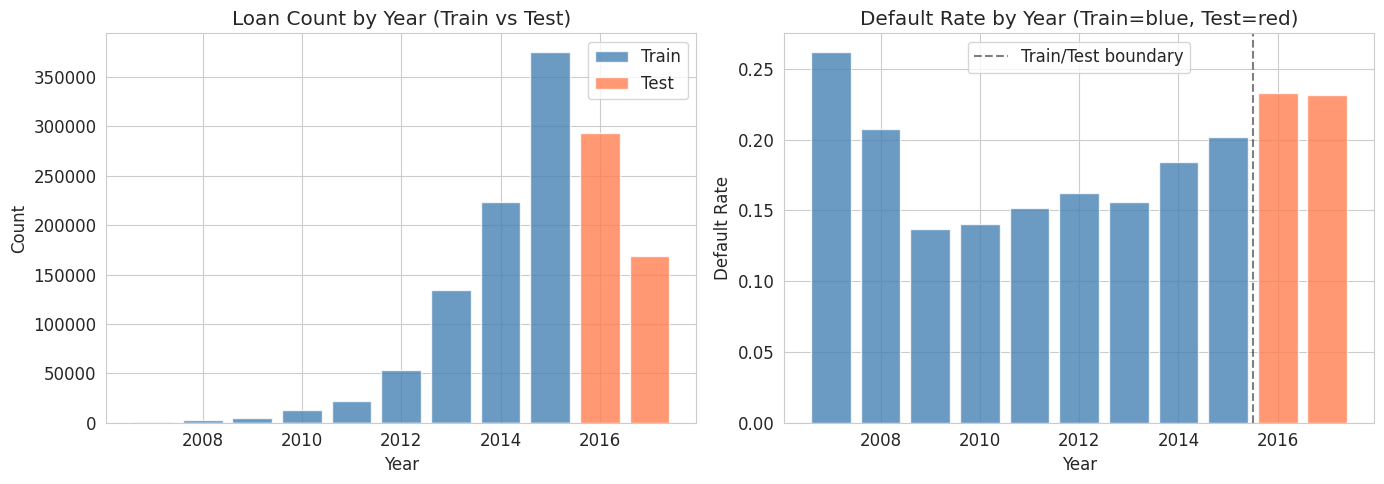

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train vs Test volume
yr_train = train['issue_year'].value_counts().sort_index()
yr_test = test['issue_year'].value_counts().sort_index()

all_years = range(2007, 2018)
train_counts = [yr_train.get(y, 0) for y in all_years]
test_counts = [yr_test.get(y, 0) for y in all_years]

axes[0].bar(all_years, train_counts, color='steelblue', label='Train', alpha=0.8)
axes[0].bar(all_years, test_counts, color='coral', label='Test', alpha=0.8)
axes[0].set_title('Loan Count by Year (Train vs Test)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].legend()

# Default rate by year
yr_default = df.groupby('issue_year')['default'].mean()
colors = ['steelblue' if y <= 2015 else 'coral' for y in yr_default.index]
axes[1].bar(yr_default.index, yr_default.values, color=colors, alpha=0.8)
axes[1].set_title('Default Rate by Year (Train=blue, Test=red)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Default Rate')
axes[1].axvline(x=2015.5, color='black', linestyle='--', alpha=0.5, label='Train/Test boundary')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Create Defaulted Loans Subset (for EAD & LGD)

**260,486 defaulted loans** (excluding 2018) with recovery and exposure data reloaded from raw dataset.

| Metric | Mean | Median | Std | Range |
|--------|:----:|:------:|:---:|:-----:|
| **EAD %** (outstanding/funded) | 0.69 | 0.74 | 0.22 | [0, 1] |
| **Recovery Rate** | 0.08 | 0.06 | — | [0, 1] |
| **LGD** (1 - recovery) | 0.92 | 0.94 | 0.10 | [0, 1] |

Both EAD and LGD are clipped to [0, 1] — the raw data had a few anomalies (recovery > funded amount) that were cleaned. LGD is heavily right-skewed with a large spike at 1.0 (zero recovery), which will inform our modeling approach (beta regression or two-stage model).

In [46]:
# Reload raw data to get the leakage columns we need for EAD/LGD targets
df_raw = pd.read_csv('../data/df_model_raw.csv', low_memory=False,
                      usecols=['default', 'loan_amnt', 'funded_amnt', 'total_rec_prncp',
                               'recoveries', 'issue_d'])

df_raw['issue_d_parsed'] = pd.to_datetime(df_raw['issue_d'], format='%b-%Y')
df_raw['issue_year'] = df_raw['issue_d_parsed'].dt.year

# Filter to defaults only, exclude 2018
df_defaulted = df_raw[(df_raw['default'] == 1) & (df_raw['issue_year'] <= 2017)].copy()

# EAD: outstanding balance as fraction of funded amount
df_defaulted['ead_pct'] = (
    (df_defaulted['funded_amnt'] - df_defaulted['total_rec_prncp']) / 
    df_defaulted['funded_amnt']
).clip(0, 1)

# LGD: 1 - recovery rate
df_defaulted['recovery_rate'] = (
    df_defaulted['recoveries'] / df_defaulted['funded_amnt']
).clip(0, 1)
df_defaulted['lgd'] = (1 - df_defaulted['recovery_rate']).clip(0, 1)

print(f"Defaulted loans (excl. 2018): {len(df_defaulted):,}")
print(f"\nEAD % stats:")
print(df_defaulted['ead_pct'].describe())
print(f"\nLGD stats:")
print(df_defaulted['lgd'].describe())

del df_raw

Defaulted loans (excl. 2018): 260,486

EAD % stats:
count   260486.00
mean         0.69
std          0.22
min          0.00
25%          0.56
50%          0.74
75%          0.86
max          1.00
Name: ead_pct, dtype: float64

LGD stats:
count   260486.00
mean         0.92
std          0.10
min          0.00
25%          0.89
50%          0.94
75%          1.00
max          1.00
Name: lgd, dtype: float64


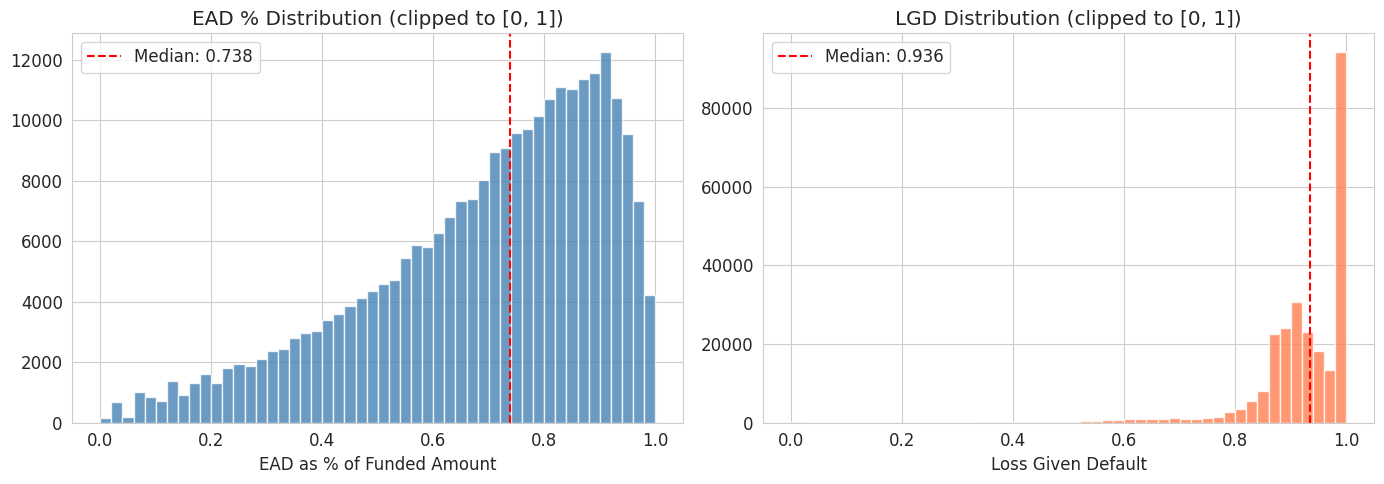

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_defaulted['ead_pct'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('EAD % Distribution (clipped to [0, 1])')
axes[0].set_xlabel('EAD as % of Funded Amount')
axes[0].axvline(df_defaulted['ead_pct'].median(), color='red', linestyle='--',
                label=f"Median: {df_defaulted['ead_pct'].median():.3f}")
axes[0].legend()

axes[1].hist(df_defaulted['lgd'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('LGD Distribution (clipped to [0, 1])')
axes[1].set_xlabel('Loss Given Default')
axes[1].axvline(df_defaulted['lgd'].median(), color='red', linestyle='--',
                label=f"Median: {df_defaulted['lgd'].median():.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Save Processed Datasets

In [48]:
train.to_csv('../data/train.csv', index=False)
test.to_csv('../data/test.csv', index=False)
df_defaulted.to_csv('../data/df_defaulted.csv', index=False)

print("Saved:")
print(f"  train.csv:        {train.shape} — 2007-2015 loans")
print(f"  test.csv:         {test.shape} — 2016-2017 loans")
print(f"  df_defaulted.csv: {df_defaulted.shape} — defaulted loans for EAD/LGD")

Saved:
  train.csv:        (829355, 101) — 2007-2015 loans
  test.csv:         (462426, 101) — 2016-2017 loans
  df_defaulted.csv: (260486, 11) — defaulted loans for EAD/LGD


## 10. Preprocessing Summary

**Pipeline: 157 columns → 91 dropped → 66 remaining → 35 missing flags added → 101 final columns**

**Columns removed (91):**
- 38 leakage (post-outcome payment/recovery/settlement/hardship)
- 7 ID/text/URL (non-predictive identifiers)
- 7 single-value (zero variance: `pymnt_plan`, `policy_code`, etc.)
- 58 high-missing >50% (joint app `sec_app_*`, delinquency history `mths_since_*`, `desc`)
- 4 redundant (`funded_amnt`, `funded_amnt_inv`, `grade`, `loan_status`)
- 5 EDA temp (`fico_avg`, `fico_bin`, `issue_date`, `issue_month`, `issue_year`)

**Features parsed:**
- `term` → integer (36/60)
- `emp_length` → numeric 0–10 (78,550 missing — 5.8%)
- `earliest_cr_line` → `credit_history_months` (mean 195 months)
- `home_ownership` → 4 categories (NONE/ANY merged into OTHER)
- `application_type` → binary `is_joint_app` (1.9% joint)
- `initial_list_status` → binary (58% whole, 42% fractional)
- `fico_range_low/high` → single `fico_score` (mean 698, range 612–848)
- `issue_d` → `issue_year` + `issue_month`

**Missing values (50 columns):**
- 35 `_missing` indicator flags created for columns with >1% missing
- All numeric imputed with median; 0 categorical columns had missing
- **Final: 0 missing values across entire dataset**

**Outliers:**
- 8 features Winsorized at 99.5th percentile (e.g., `annual_inc` capped at $325K from $11M max, `dti` capped at 40 from 999)
- `revol_util` hard-capped at 100%, `dti` floored at 0

**Train/Test split (vintage-based):**
- Train (2007–2015): **829,355 loans**, 18.46% default rate
- Test (2016–2017): **462,426 loans**, 23.23% default rate
- 2018 excluded (56,318 loans — right-censored)

**Saved datasets:**
- `train.csv`: (829,355 x 101) — training features + target
- `test.csv`: (462,426 x 101) — test features + target
- `df_defaulted.csv`: (260,486 x 11) — defaulted loans with EAD/LGD targets

**Next Steps → Notebook 03 (Feature Engineering):**
- Encode categoricals: sub_grade (ordinal), purpose & home_ownership (one-hot), addr_state (target encoding), verification_status (one-hot)
- Create interaction features and financial ratios
- Feature selection via importance ranking and correlation filtering